In [74]:
import pandas as pd
import numpy as np
from typing import List, Tuple
from scipy.interpolate import interp1d
from datetime import timedelta
from epiweeks import Week
import epiweeks
from sodapy import Socrata
from datetime import datetime
from datetime import date, timedelta
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import seaborn as sns
from scorepi import *
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from ensemble import create_ensemble_method1, create_categorical_ensemble_quantile, create_activity_level_ensemble
from pathlib import Path
import sys

In [75]:
def pull_flusight_predictions(model,date):
    """pull_scenario_modeling_hub_predictions. Load predictions of the model saved by the scenario modeling
    hub.

    Parameters
    ----------
    model : str
        Model name on the
    dates : list or string
        List of potential dates in the iso format, e.g., 'yyyy-mm-dd', for the submission.
    """
    predictions = None
    
    url = f"https://raw.githubusercontent.com/cdcepi/Flusight-forecast-hub/main/model-output/{model}/{date}-{model}"
    for ext in [".csv",".gz",".zip",".csv.zip",".csv.gz", '.parquet']:
        try:
            if ext == '.parquet':
                predictions = pd.read_parquet(url+ext,engine='auto')
                predictions['location'] = predictions['location'].astype(str)
                predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
            else:
                predictions = pd.read_csv(url+ext,dtype={'location':str},parse_dates=['target_end_date'])
        except:
            pass
    if predictions is None:
        print(f"Data for model {model} and date {date} unavailable")
    return predictions


def pull_surveillance_data():
    mapping = {'death':'Deaths', 'case':'Cases', 'hospitalization': 'Hospitalizations'}
    
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})



def create_categorical_ensemble_quantile(df):
    obs = pd.read_csv('https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/target-data/target-hospital-admissions.csv')
    obs['date'] = pd.to_datetime(obs['date'])
    locations = pd.read_csv('locations.csv')

    TREND_MAP = {0: {  # 1-week ahead
                "stable_rate_max": 0.3,
                "stable_count_max": 10,
                "large_threshold": 1.7, },
            1: {  # 2-week ahead
                "stable_rate_max": 0.5,
                "stable_count_max": 10,
                "large_threshold": 3.0,},
            2: {  # 3-week ahead
                "stable_rate_max": 0.7,
                "stable_count_max": 10,
                "large_threshold": 4.0,},
            3: {  # 4- & 5-week ahead
                "stable_rate_max": 1.0,
                "stable_count_max": 10,
                "large_threshold": 5.0,},}
    
    results = []
    
    # Get all unique combinations
    combinations = df[['reference_date', 'horizon', 'location']].drop_duplicates()
    
    for idx, row in combinations.iterrows():
        reference_date = row['reference_date']
        horizon = row['horizon']
        loc = row['location']
        
        try:
            # Filter data for this combination
            df_subset = df[
                (df.reference_date == reference_date) & 
                (df.horizon == horizon) & 
                (df.location == loc)
            ].sort_values(by='output_type_id')
            
            if len(df_subset) == 0:
                print(f"No data for {loc}, horizon {horizon}, reference_date {reference_date}")
                continue
            
            # Get target_end_date (should be same for all quantiles in this subset)
            target_end_date = df_subset['target_end_date'].iloc[0]
            

             # Get observed value
            last_obs = pd.to_datetime(reference_date) - timedelta(days=7)

            obs_subset = obs[(obs.location == loc) &  (obs.date == last_obs)]

            if len(obs_subset) == 0:
                print(f"No observation for {loc} on {last_obs}")
                continue
                
            val = obs_subset.value.values[0]
            
            # Calculate count differences
            df_subset = df_subset.copy()
            df_subset['count_diff'] = df_subset['value'] - val
            
            quantiles = list(df_subset['output_type_id'])
            count_changes = list(df_subset['count_diff'])
            
            # Get population
            pop_subset = locations[locations.location == loc]
            if len(pop_subset) == 0:
                print(f"No population data for {loc}")
                continue
                
            population = pop_subset.population.values[0]
            rate_changes = (np.array(count_changes) / population) * 100000
            
            # Create CDFs
            cdf_count = interp1d(
                count_changes, quantiles, 
                kind='linear', bounds_error=False, fill_value=(0, 1)
            )
            cdf_rate = interp1d(
                rate_changes, quantiles,
                kind='linear', bounds_error=False, fill_value=(0, 1)
            )
            
            # Get thresholds
            trends = TREND_MAP[horizon]
            countmap = trends['stable_count_max']
            ratemap = trends['stable_rate_max']
            largemap = trends['large_threshold']
            
            # Get CDF values at boundaries
            p_count_minus10 = float(cdf_count(-countmap))
            p_count_plus10 = float(cdf_count(countmap))
            p_rate_decrease = float(cdf_rate(-ratemap))
            p_rate_increase = float(cdf_rate(ratemap))
            p_rate_largedec = float(cdf_rate(-largemap))
            p_rate_largeinc = float(cdf_rate(largemap))
            
            # Calculate rates at count boundaries
            rate_count10 = (countmap / population) * 100000
            rate_countminus10 = (-countmap / population) * 100000
            
            # Initialize probabilities with defaults (rate-based)
            probs = {}
            probs['stable'] = p_rate_increase - p_rate_decrease
            probs['increase'] = p_rate_largeinc - p_rate_increase
            probs['large_increase'] = 1 - p_rate_largeinc
            probs['decrease'] = p_rate_decrease - p_rate_largedec
            probs['large_decrease'] = p_rate_largedec
            
            # Apply logic based on which constraints are binding
            if rate_count10 < ratemap and rate_countminus10 > -ratemap:
                # Rate is wider on both sides - keep defaults
                pass
                
            elif rate_count10 < largemap and rate_count10 >= ratemap and rate_countminus10 > -ratemap:
                probs['stable'] = p_count_plus10 - p_rate_decrease
                probs['increase'] = p_rate_largeinc - p_count_plus10
                
            elif rate_count10 >= largemap and rate_countminus10 > -ratemap:
                probs['stable'] = p_count_plus10 - p_rate_decrease
                probs['increase'] = 0
                probs['large_increase'] = 1 - p_count_plus10
                
            elif rate_count10 < ratemap and rate_countminus10 > -largemap and rate_countminus10 <= -ratemap:
                probs['stable'] = p_rate_increase - p_count_minus10
                probs['decrease'] = p_count_minus10 - p_rate_largedec
                
            elif rate_count10 < ratemap and rate_countminus10 <= -largemap:
                probs['stable'] = p_rate_increase - p_count_minus10
                probs['decrease'] = 0
                probs['large_decrease'] = p_count_minus10
                
            elif rate_count10 < largemap and rate_countminus10 > -largemap and rate_countminus10 <= -ratemap and rate_count10 >= ratemap:
                probs['stable'] = p_count_plus10 - p_count_minus10
                probs['increase'] = p_rate_largeinc - p_count_plus10
                probs['decrease'] = p_count_minus10 - p_rate_largedec
                
            elif rate_count10 >= largemap and rate_countminus10 > -largemap and rate_countminus10 <= -ratemap:
                probs['stable'] = p_count_plus10 - p_count_minus10
                probs['increase'] = 0
                probs['large_increase'] = 1 - p_count_plus10
                probs['decrease'] = p_count_minus10 - p_rate_largedec
                
            elif rate_count10 < largemap and rate_countminus10 <= -largemap and rate_count10 >= ratemap:
                probs['stable'] = p_count_plus10 - p_count_minus10
                probs['decrease'] = 0
                probs['large_decrease'] = p_count_minus10
                probs['increase'] = p_rate_largeinc - p_count_plus10
                
            elif rate_count10 >= largemap and rate_countminus10 <= -largemap:
                probs['stable'] = p_count_plus10 - p_count_minus10
                probs['decrease'] = 0
                probs['increase'] = 0
                probs['large_decrease'] = p_count_minus10
                probs['large_increase'] = 1 - p_count_plus10
                
            else:
                probs['stable'] = 1
                probs['increase'] = 0
                probs['large_increase'] = 0
                probs['decrease'] = 0
                probs['large_decrease'] = 0
            
            # Verify probabilities sum to 1
            total = sum(probs.values())
            if abs(total - 1.0) > 0.01:
                print(f"WARNING: Probabilities don't sum to 1 for {loc}, horizon {horizon}, date {reference_date}: {total:.4f}")
            
            # Create output rows
            for category, probability in probs.items():
                results.append({
                    'reference_date': reference_date,
                    'target_end_date': target_end_date,
                    'horizon': horizon,
                    'location': loc,
                    'target': 'wk flu hosp rate change',
                    'output_type': 'pmf',
                    'output_type_id': category,
                    'value': probability
                })
                
        except Exception as e:
            print(f"Error processing {loc}, horizon {horizon}, reference_date {reference_date}: {str(e)}")
            continue
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Reorder columns
    results_df = results_df[[
        'target_end_date', 'horizon', 'output_type_id', 'value', 
        'location', 'target','output_type', 'reference_date'
    ]]
    
    return results_df


In [76]:
models = ['MIGHTE-Nsemble', 'MIGHTE-Joint', 'CEPH-Rtrend_fluH', 'MOBS-EpyStrain_Flu', 'MOBS-GLEAM_RL_FLUH', 
    'NU-PGF_FLUH', 'NEU_ISI-FluBcast',  'NEU_ISI-AdaptiveEnsemble','Gatech-ensemble_prob',
    'Gatech-ensemble_stat']

reference_date = str(Week.fromdate(datetime.now()).enddate())
#reference_date = '2026-02-14'

forecasts = pd.DataFrame()
for model in models:
    try:
        df = pull_flusight_predictions(model,reference_date)

        df = df[(df.target=='wk inc flu hosp') & (df.horizon>=0)]
        df['model'] = model
        df['output_type_id'] = df['output_type_id'].astype(str)

        forecasts = pd.concat([forecasts, df])
        
    except:
        print(f'')
        
model_counts = forecasts.groupby('location')['model'].nunique().reset_index()
model_counts.columns = ['location', 'num_models']

In [77]:
remove_loc = model_counts[model_counts.num_models<5].location.unique()

print(model_counts[model_counts.num_models<5].location.unique())

[]


In [78]:
quantile_ensemble = create_ensemble_method1(forecasts)

#dont submit locations with fewer than 5 models
quantile_ensemble = quantile_ensemble[~quantile_ensemble.location.isin(remove_loc)]

In [80]:
quantile_ensemble

,reference_date,location,horizon,target,target_end_date,output_type,output_type_id,value
0,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.01,86.0
1,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.025,97.0
2,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.05,104.0
3,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.1,114.0
4,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.15,121.0
...,...,...,...,...,...,...,...,...
4871,2026-03-07,US,3,wk inc flu hosp,2026-03-28,quantile,0.85,5944.0
4872,2026-03-07,US,3,wk inc flu hosp,2026-03-28,quantile,0.9,6542.0
4873,2026-03-07,US,3,wk inc flu hosp,2026-03-28,quantile,0.95,7437.0
4874,2026-03-07,US,3,wk inc flu hosp,2026-03-28,quantile,0.975,8806.0


In [ ]:
# categorical ensemble

In [81]:
categorical_ensemble = create_categorical_ensemble_quantile(quantile_ensemble)

In [82]:
categorical_ensemble

,target_end_date,horizon,output_type_id,value,location,target,output_type,reference_date
0,2026-03-07,0,stable,0.244927,01,wk flu hosp rate change,pmf,2026-03-07
1,2026-03-07,0,increase,0.250625,01,wk flu hosp rate change,pmf,2026-03-07
2,2026-03-07,0,large_increase,0.010282,01,wk flu hosp rate change,pmf,2026-03-07
3,2026-03-07,0,decrease,0.494166,01,wk flu hosp rate change,pmf,2026-03-07
4,2026-03-07,0,large_decrease,0.000000,01,wk flu hosp rate change,pmf,2026-03-07
...,...,...,...,...,...,...,...,...
1055,2026-03-28,3,stable,0.083693,US,wk flu hosp rate change,pmf,2026-03-07
1056,2026-03-28,3,increase,0.000000,US,wk flu hosp rate change,pmf,2026-03-07
1057,2026-03-28,3,large_increase,0.000000,US,wk flu hosp rate change,pmf,2026-03-07
1058,2026-03-28,3,decrease,0.916307,US,wk flu hosp rate change,pmf,2026-03-07


In [83]:
submissiondf = pd.concat([quantile_ensemble, categorical_ensemble])

In [84]:
modelname = 'Epistorm-Ensemble_Flu'
submissiondf.to_csv(f'./submissions/{reference_date}-{modelname}.csv', index=False)

In [85]:
pd.read_csv(f'./submissions/{reference_date}-{modelname}.csv')

,reference_date,location,horizon,target,target_end_date,output_type,output_type_id,value
0,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.01,86.000000
1,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.025,97.000000
2,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.05,104.000000
3,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.1,114.000000
4,2026-03-07,01,0,wk inc flu hosp,2026-03-07,quantile,0.15,121.000000
...,...,...,...,...,...,...,...,...
5931,2026-03-07,US,3,wk flu hosp rate change,2026-03-28,pmf,stable,0.083693
5932,2026-03-07,US,3,wk flu hosp rate change,2026-03-28,pmf,increase,0.000000
5933,2026-03-07,US,3,wk flu hosp rate change,2026-03-28,pmf,large_increase,0.000000
5934,2026-03-07,US,3,wk flu hosp rate change,2026-03-28,pmf,decrease,0.916307


# plot forecasts

In [86]:
def set_date_axis_fmt(ax):
    # Set the locator
    locator = mdates.MonthLocator(interval=1) # every month
    # Specify the format
    fmt = mdates.DateFormatter('%b %Y')

    X = ax.xaxis
    X.set_major_locator(locator)
    # Specify formatter
    X.set_major_formatter(fmt)


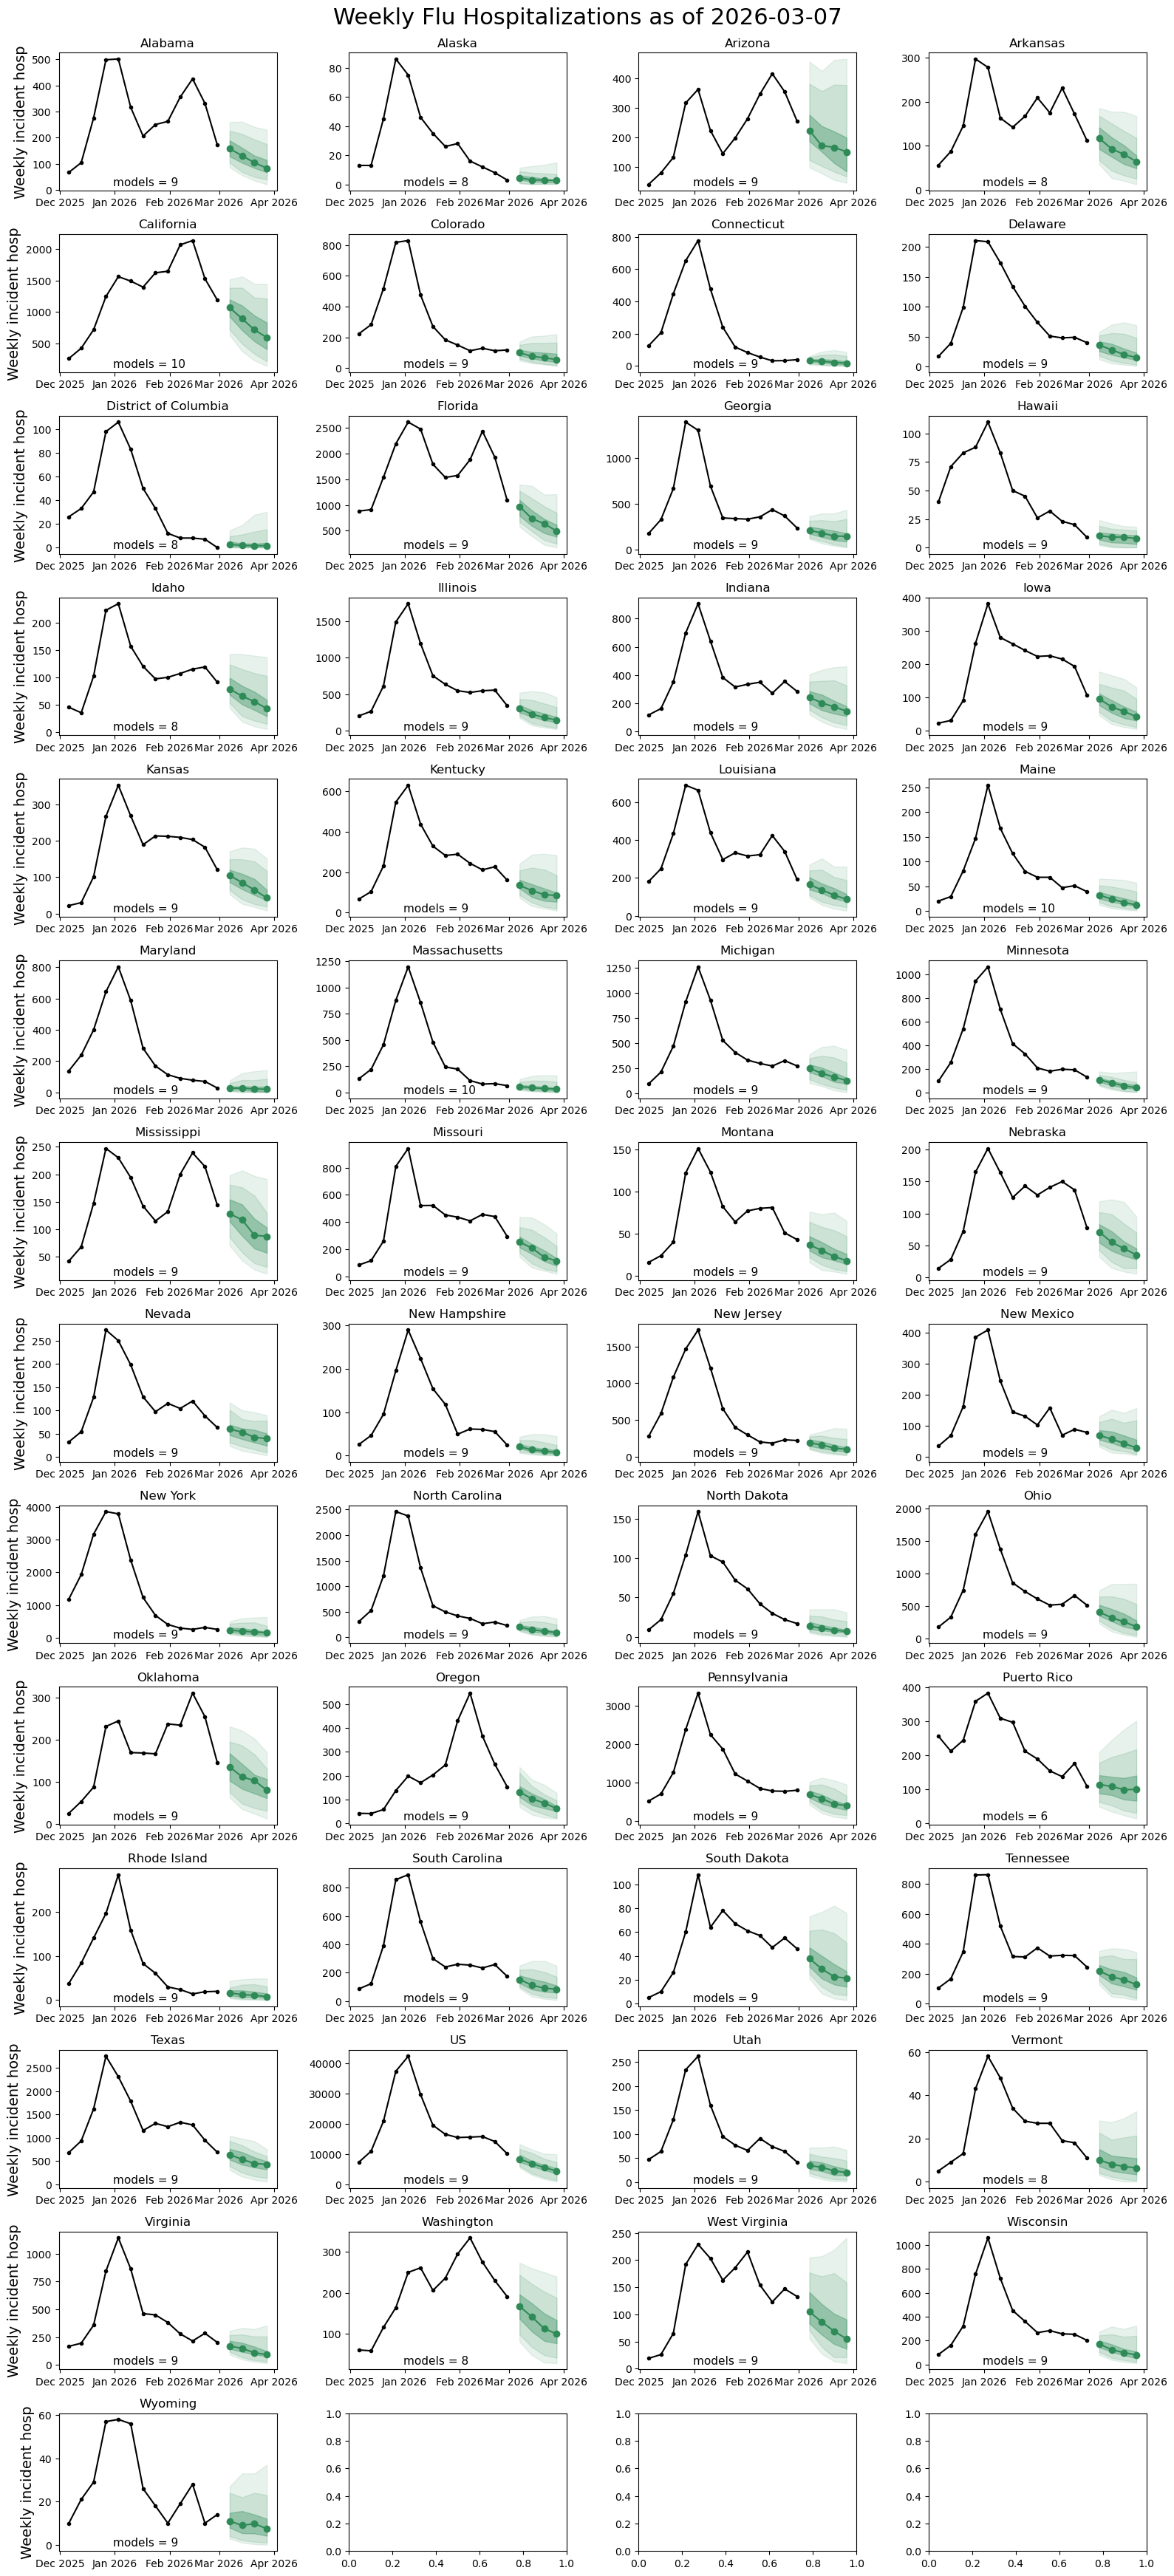

In [90]:
surv = pull_surveillance_data()

locations = pd.read_csv('./locations.csv')
#locations['location'] = locations['location'].apply(lambda x: '0' + x if x!='US' and int(x)<10 else x)
surv = surv.merge(locations)

preds = pd.read_csv(f'./submissions/{reference_date}-{modelname}.csv')
preds = preds.merge(locations)
preds = preds.sort_values(by='location_name')

fig, ax = plt.subplots(14,4,figsize = (16,2.5*14))

fig.suptitle(f"Weekly Flu Hospitalizations as of {reference_date}", fontsize = 22, y = .995)


intervals = [(0.01,0.99),(0.05,0.95),(0.25,0.75)]
map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1
color = 'seagreen'

r = 0
c = 0

surv['date'] = pd.to_datetime(surv['date'])

surv = surv.sort_values(by=['location_name','date'])
for loc in surv.location.unique():    
    if c == 4:
        c = 0
        r+=1

    
    d = surv[(surv.location==loc) & (surv.date>=pd.to_datetime('2025-12-01'))]
    ax[r,c].plot(d.date,d['value'],'.-',color='k',label='Weekly incident hosp')
    
    #dfilt = d[d.date>=pd.to_datetime(date)]
    #ax[r,c].plot(dfilt.date,dfilt['value'],'o',mfc='w', mec='k')
    
    #last_week = (pd.to_datetime(date) - timedelta(days=7)).strftime("%Y-%m-%d")  
    
    
    predictions = Predictions(preds[(preds.location==loc) & (preds.horizon>=0) &\
                                   (preds.target == 'wk inc flu hosp')], t_col='target_end_date', 
                              quantile_col='output_type_id', type_col='horizon')
    
    predictions['output_type_id'] = predictions['output_type_id'].astype(float)
    
    t = np.unique(predictions.get_t())
    predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
     #intervals
    for interval in intervals:
        q_low,q_upp = interval
        interval_range = q_upp - q_low
        alpha = map_alpha(interval_range)
        pred_low = predictions.get_quantile(q_low, )
        pred_upp = predictions.get_quantile(q_upp, )
        ax[r,c].fill_between(predictions.target_end_date.unique(),pred_upp,pred_low, color=color, alpha=alpha,
                               label=fr"PI {int(round(interval_range*100))} %")

    pred_point = predictions.get_point()
    if len(pred_point) > 0:
        ax[r,c].plot(predictions.target_end_date.unique(),pred_point,'-o',color=color)

    
    set_date_axis_fmt(ax[r,c])
      
    ax[r,c].set_title(locations[locations.location==loc].location_name.unique()[0], fontsize=12)    
        
    ax[r,c].text(0.25, 0.1, f"models = {model_counts.loc[model_counts['location']==loc, 'num_models'].values[0]}",
         transform=ax[r,c].transAxes, va='top', ha='left', fontsize=11)
    
    if c==0:
        ax[r,c].set_ylabel('Weekly incident hosp', fontsize=14)
    
    c+=1
    
    
plt.tight_layout()
plt.savefig(f'./submissions/figs/{modelname}_{reference_date}_hosp_quantile.pdf')
plt.show()

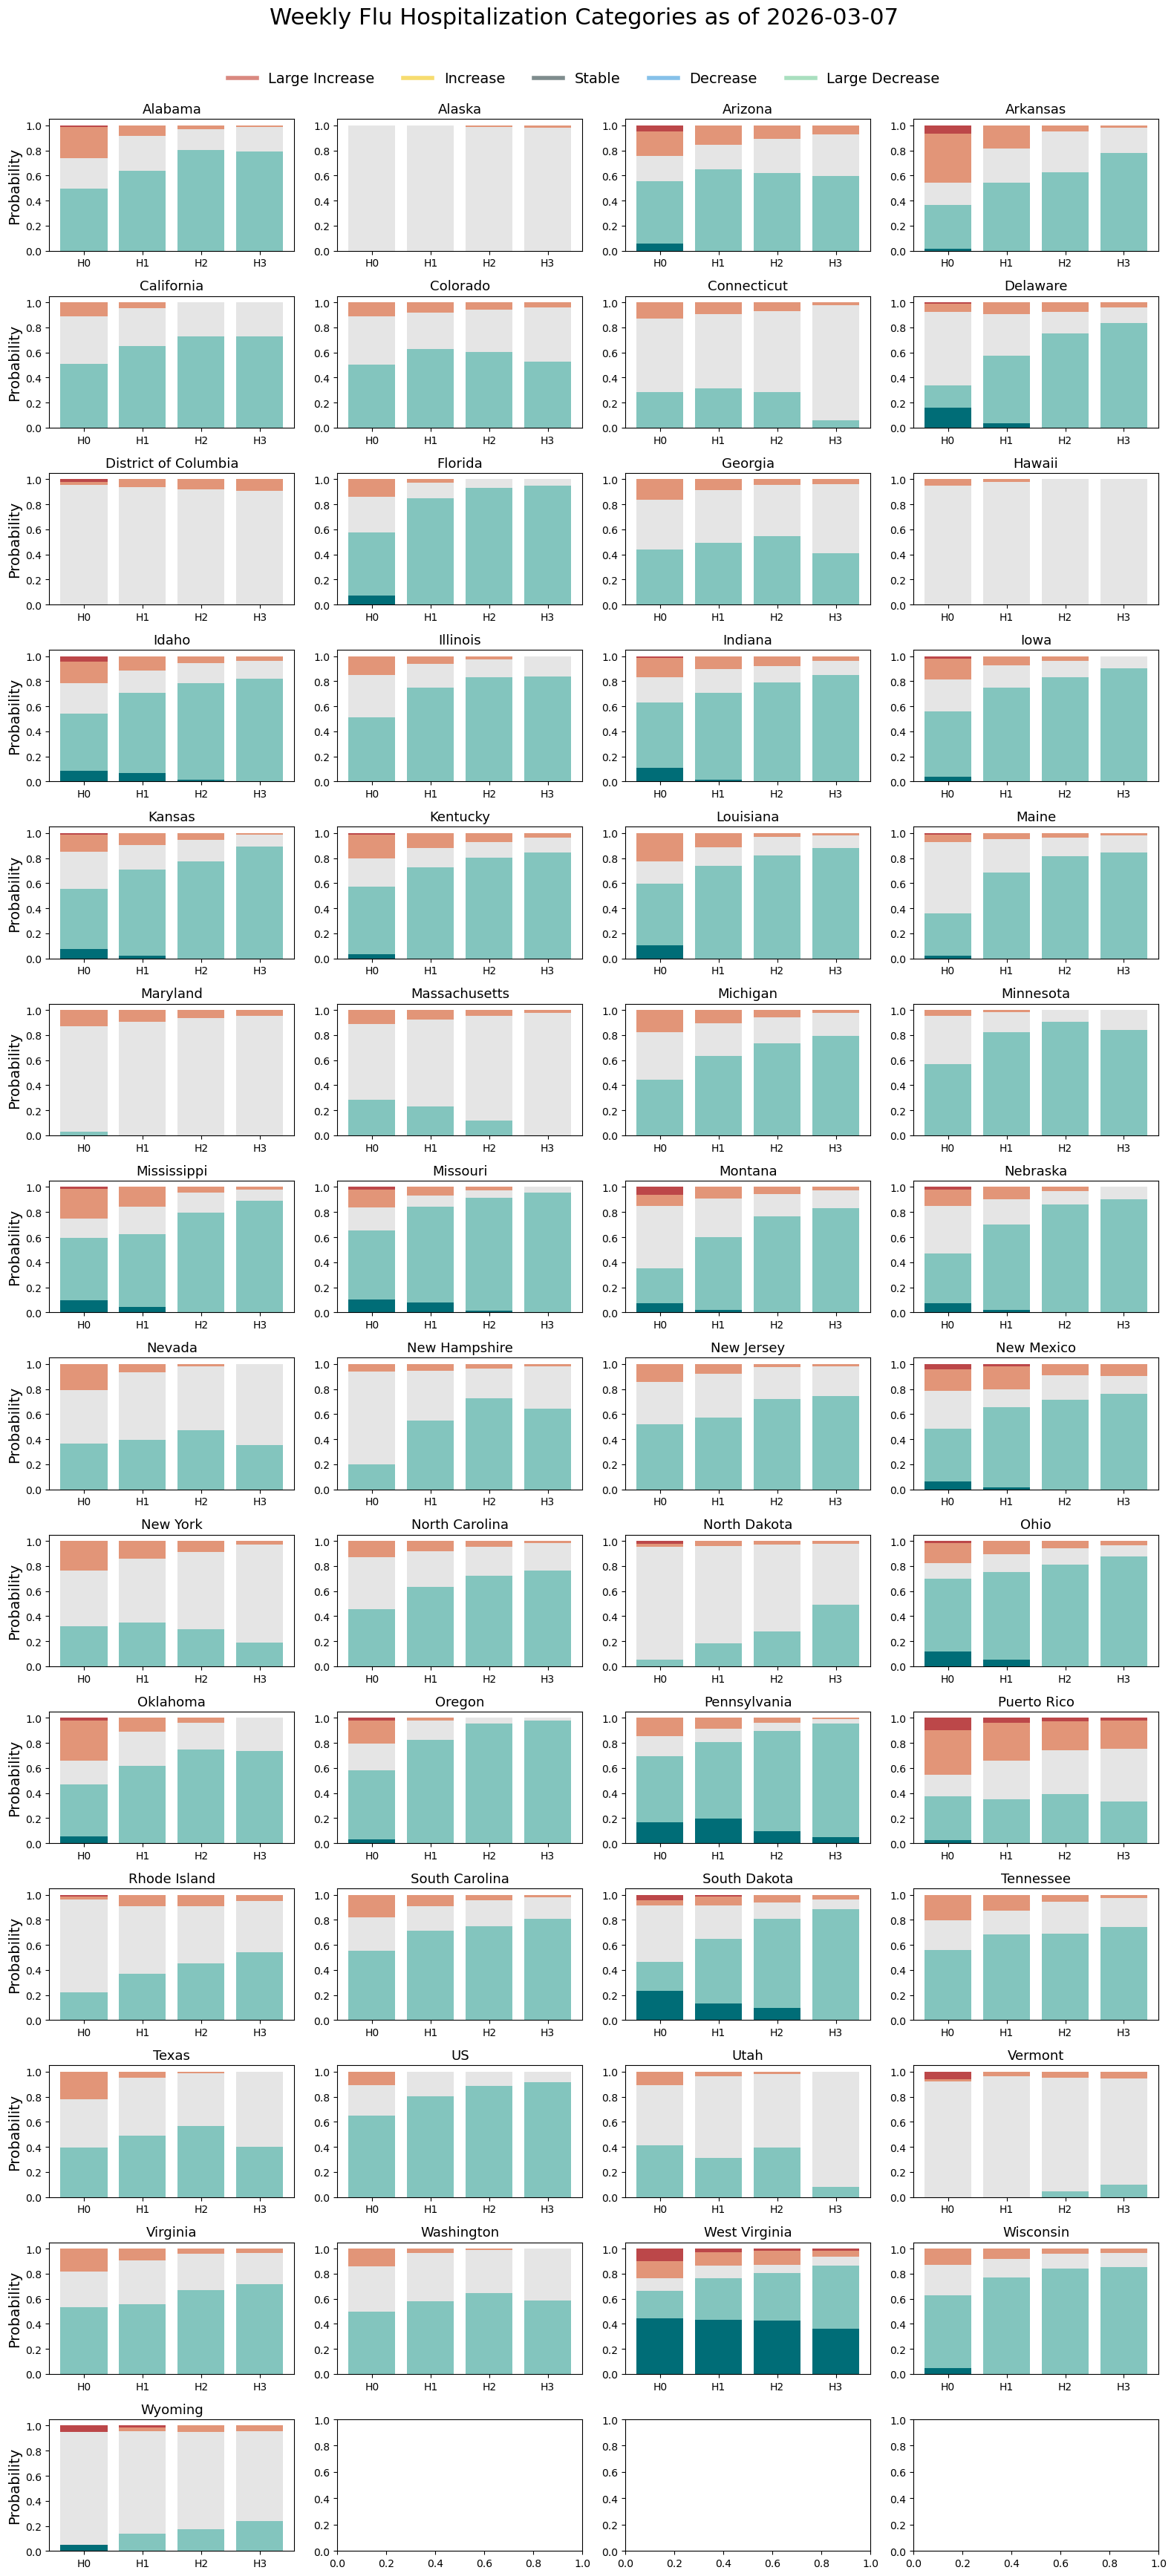

In [88]:
locations = pd.read_csv('./locations.csv')

preds = pd.read_csv(f'./submissions/{reference_date}-{modelname}.csv')
preds = preds.merge(locations)
preds = preds.sort_values(by='location_name')

fig, ax = plt.subplots(14,4,figsize = (16,2.5*14))
fig.suptitle(f"Weekly Flu Hospitalization Categories as of {reference_date}", fontsize = 22, y = .99)

r = 0
c = 0


for loc in preds.location.unique():    
    if c == 4:
        c = 0
        r+=1
    
    df_forecast = Predictions(preds[(preds.location==loc) & (preds.horizon>=0) &\
                                   (preds.target == 'wk flu hosp rate change')], t_col='target_end_date', 
                              quantile_col='output_type_id', type_col='horizon')
    
       
    if df_forecast.shape[0]!=0:
        stable = df_forecast[df_forecast['output_type_id']=='stable'].sort_values(by = "target_end_date")
        increase = df_forecast[df_forecast['output_type_id']=='increase'].sort_values(by = "target_end_date")
        decrease = df_forecast[df_forecast['output_type_id']=='decrease'].sort_values(by = "target_end_date")
        large_increase = df_forecast[df_forecast['output_type_id']=='large_increase'].sort_values(by = "target_end_date")
        large_decrease = df_forecast[df_forecast['output_type_id']=='large_decrease'].sort_values(by = "target_end_date")

        #color scheme
        colors = {
            'large_increase': '#bc4749',
            'increase': '#e29578',
            'stable': '#e5e5e5',
            'decrease': '#83c5be',
            'large_decrease': '#006d77'
        }

        #plot stacked bars
        ax[r,c].bar(range(0,4), large_decrease['value'].values, color=colors['large_decrease'], label="Large Decrease")
        ax[r,c].bar(range(0,4), decrease['value'].values, bottom=large_decrease['value'].values, color=colors['decrease'], label="Decrease")
        ax[r,c].bar(range(0,4), stable['value'].values, bottom=large_decrease['value'].values + decrease['value'].values, color=colors['stable'], label="Stable")
        ax[r,c].bar(range(0,4), increase['value'].values, bottom=large_decrease['value'].values + decrease['value'].values + stable['value'].values, color=colors['increase'], label="Increase")
        ax[r,c].bar(range(0,4), large_increase['value'].values, bottom=large_decrease['value'].values + decrease['value'].values + stable['value'].values + increase['value'].values, color=colors['large_increase'], label="Large Increase")


    ax[r,c].set_xticks(range(0,4))
    ax[r,c].set_xticklabels(['H0','H1','H2','H3'])
    ax[r,c].set_ylim(0,1.05)

      
    ax[r,c].set_title(locations[locations.location==loc].location_name.unique()[0], fontsize=13)    
        
    
    if c==0:
        ax[r,c].set_ylabel('Probability', fontsize=14)
    
    c+=1
    
    
# ---- Global legend for action colors ----
legend_elements = [
    Line2D([0], [0], color="#d98880", lw=4, label="Large Increase"),
    Line2D([0], [0], color="#f7dc6f", lw=4, label="Increase"),
    Line2D([0], [0], color="#7f8c8d", lw=4, label="Stable"),
    Line2D([0], [0], color="#85c1e9", lw=4, label="Decrease"),
    Line2D([0], [0], color="#a9dfbf", lw=4, label="Large Decrease"),
]

plt.subplots_adjust(top=0.8)
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, .97),
    ncol=5,
    fontsize=14,
    frameon=False,
)    

    
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.savefig(f'./submissions/figs/{modelname}_{reference_date}_hosp_category.pdf')
plt.show()

# Plot past forecasts

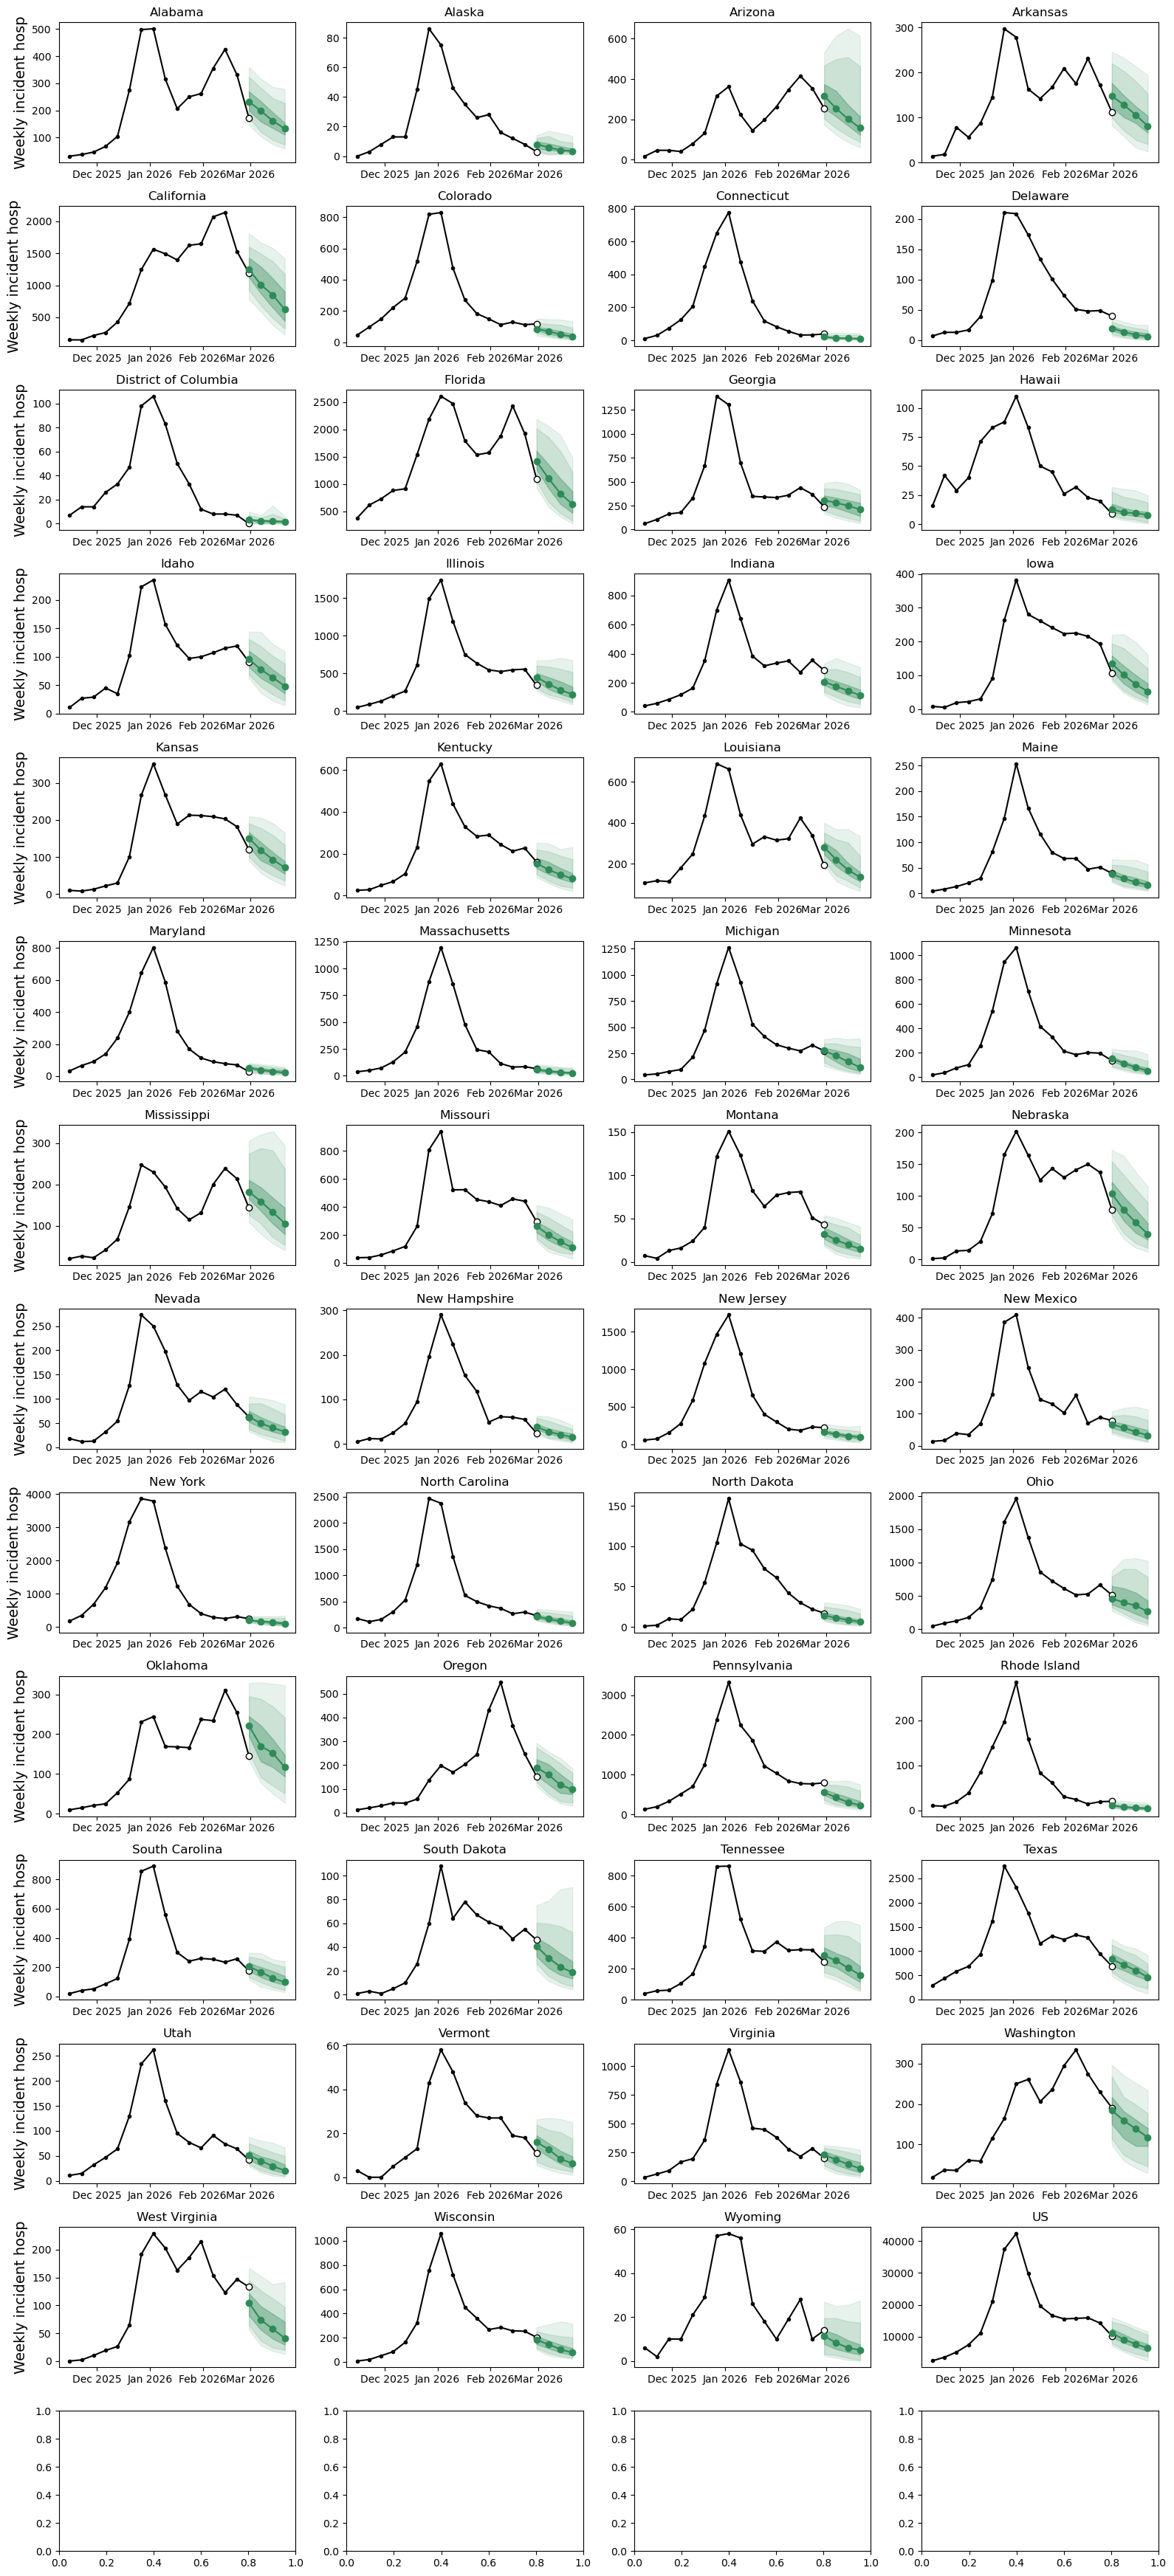

In [91]:
surv = pull_surveillance_data()

locations = pd.read_csv('./locations.csv')
#locations['location'] = locations['location'].apply(lambda x: '0' + x if x!='US' and int(x)<10 else x)
surv = surv.merge(locations)

date = '2026-02-28'
preds = pd.read_csv(f'https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/model-output/Epistorm-Ensemble_Flu/{date}-Epistorm-Ensemble_Flu.csv')

fig, ax = plt.subplots(14,4,figsize = (16,2.5*14))

intervals = [(0.01,0.99),(0.05,0.95),(0.25,0.75)]
map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1
color = 'seagreen'

r = 0
c = 0

surv['date'] = pd.to_datetime(surv['date'])

surv = surv.sort_values(by=['location_name','date'])
for loc in preds.location.unique():    
    if c == 4:
        c = 0
        r+=1

    
    d = surv[(surv.location==loc) & (surv.date>=pd.to_datetime('2025-11-15'))]
    ax[r,c].plot(d.date,d['value'],'.-',color='k',label='Weekly incident hosp')
    
    dfilt = d[d.date>=pd.to_datetime(date)]
    ax[r,c].plot(dfilt.date,dfilt['value'],'o',mfc='w', mec='k')
    
    last_week = (pd.to_datetime(date) - timedelta(days=7)).strftime("%Y-%m-%d")
    
   # surv_old = pd.read_csv(f'https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/auxiliary-data/target-data-archive/target-hospital-admissions_{last_week}.csv')
    #surv_old['date'] = pd.to_datetime(surv_old['date'])
    #d = surv_old[(surv_old.location==loc) & (surv_old.date>=pd.to_datetime('2025-11-01'))]
    #ax[r,c].plot(d.date,d['value'],'-',color='gray',label='as_of forecast date')
    
    
    
    predictions = Predictions(preds[(preds.location==loc) & (preds.horizon>=0) &\
                                   (preds.target == 'wk inc flu hosp')], t_col='target_end_date', 
                              quantile_col='output_type_id', type_col='horizon')
    
    predictions['output_type_id'] = predictions['output_type_id'].astype(float)
    
    t = np.unique(predictions.get_t())
    predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
     #intervals
    for interval in intervals:
        q_low,q_upp = interval
        interval_range = q_upp - q_low
        alpha = map_alpha(interval_range)
        pred_low = predictions.get_quantile(q_low, )
        pred_upp = predictions.get_quantile(q_upp, )
        ax[r,c].fill_between(predictions.target_end_date.unique(),pred_upp,pred_low, color=color, alpha=alpha,
                               label=fr"PI {int(round(interval_range*100))} %")

    pred_point = predictions.get_point()
    if len(pred_point) > 0:
        ax[r,c].plot(predictions.target_end_date.unique(),pred_point,'-o',color=color)

    
    set_date_axis_fmt(ax[r,c])
      
    ax[r,c].set_title(locations[locations.location==loc].location_name.unique()[0], fontsize=12)    
        
    
    if c==0:
        ax[r,c].set_ylabel('Weekly incident hosp', fontsize=14)
    
    c+=1
    
    
plt.tight_layout()
plt.savefig(f'./submissions/retrospective_figs/Ensemble-forecast_{date}-with-history.pdf')
plt.show()

In [33]:
.75*8

6.0

In [69]:
surv[surv.location_name=='Louisiana'].location.unique()

array(['22'], dtype=object)

In [70]:
preds.location.unique()

array(['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13',
       '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48',
       '49', '50', '51', '53', '54', '55', '56', 'US'], dtype=object)

In [71]:
surv[(surv.location=='22') & (surv.date>=pd.to_datetime('2025-11-15'))]
    #ax[r,c].plot(d.date,d['value'],'.-',color='k',label='Weekly incident hosp')

,date,location,location_name,value,weekly_rate,abbreviation,population,count_rate0p3,count_rate0p5,count_rate0p7,count_rate1,count_rate1p7,count_rate3,count_rate4,count_rate5


In [73]:
surv[(surv.location=='22') ].date.unique()

array(['2022-02-05T00:00:00.000000000', '2022-02-12T00:00:00.000000000',
       '2022-02-19T00:00:00.000000000', '2022-02-26T00:00:00.000000000',
       '2022-03-05T00:00:00.000000000', '2022-03-12T00:00:00.000000000',
       '2022-03-19T00:00:00.000000000', '2022-03-26T00:00:00.000000000',
       '2022-04-02T00:00:00.000000000', '2022-04-09T00:00:00.000000000',
       '2022-04-16T00:00:00.000000000', '2022-04-23T00:00:00.000000000',
       '2022-04-30T00:00:00.000000000', '2022-05-07T00:00:00.000000000',
       '2022-05-14T00:00:00.000000000', '2022-05-21T00:00:00.000000000',
       '2022-05-28T00:00:00.000000000', '2022-06-04T00:00:00.000000000',
       '2022-06-11T00:00:00.000000000', '2022-06-18T00:00:00.000000000',
       '2022-06-25T00:00:00.000000000', '2022-07-02T00:00:00.000000000',
       '2022-07-09T00:00:00.000000000', '2022-07-16T00:00:00.000000000',
       '2022-07-23T00:00:00.000000000', '2022-07-30T00:00:00.000000000',
       '2022-08-06T00:00:00.000000000', '2022-08-13